 # Bitcoin Price Prediction


La variable objetivo es el **retorno logarítmico del precio Close**. Esta transformación garantiza estacionariedad en la serie, como se demostró en el EDA mediante el test ADF.

## Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Preprocesamiento y validación
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split temporal
from tsxv.splitTrainValTest import split_train_val_test_groupKFold

# Tests estadísticos
from statsmodels.tsa.stattools import bds
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# LIME
import lime
import lime.lime_tabular


In [2]:
# Carga y preprocesamiento de datos 
datos = pd.read_csv('data.csv')
datos['TimestampConventional'] = pd.to_datetime(datos['Timestamp'], unit='s')
datos.set_index('TimestampConventional', inplace=True)

df = datos['2019':][["Open","High","Low","Close","Volume"]].resample('15min').mean()
df = df.dropna()

print(f'Datos cargados: {df.shape[0]:,} observaciones')
print(f'Periodo: {df.index[0]} → {df.index[-1]}')

Datos cargados: 250,581 observaciones
Periodo: 2019-01-01 00:00:00 → 2026-02-24 00:00:00


El dataset queda con 250.581 observaciones y en el periodo del 2019-01-01 hasta el 2026-02-24

## Construcción de features

La variable objetivo es el **retorno logarítmico del Close**. Como el EDA mostró que 7 lags captura la memoria relevante de la serie (menor RMSE y residuos independientes según BDS), se usan **7 lags** como features de entrada.

Serie de retornos: 250,580 observaciones
Media: 0.000011 | Std: 0.002869


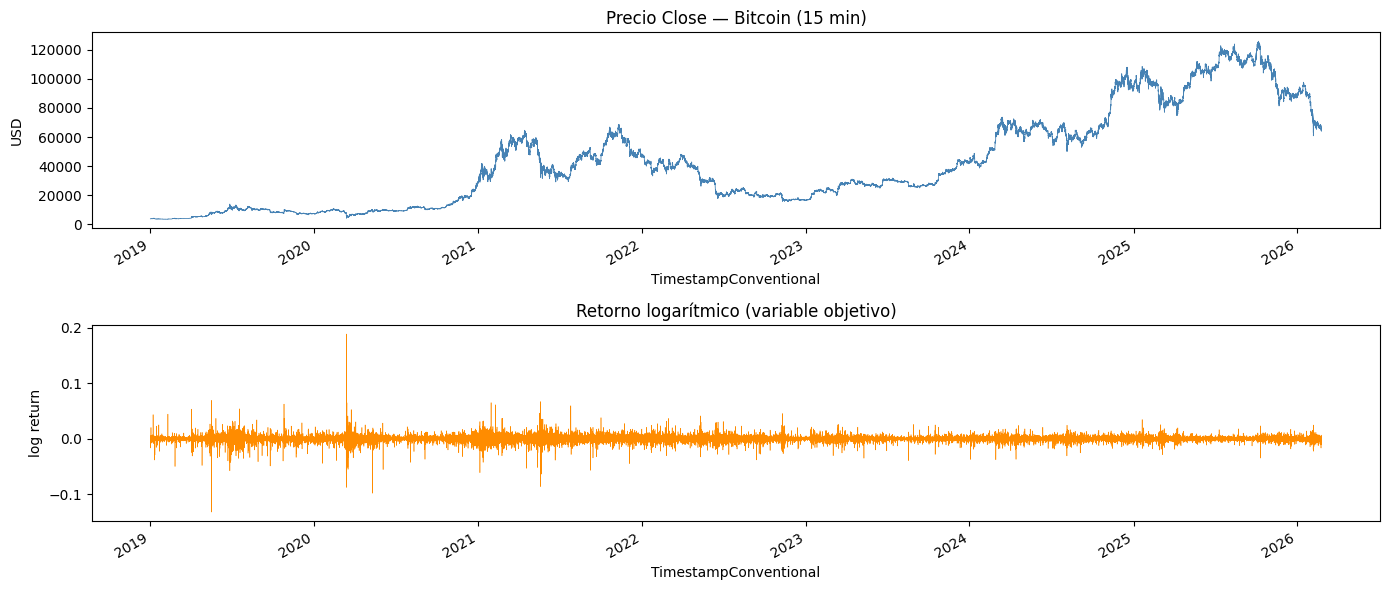

In [ ]:
# Retorno logarítmico
log_return = np.log(df['Close']).diff().dropna()

# Parámetros del problema
N_LAGS     = 7   # inputs: 7 pasos previos
N_STEPS    = 1   # output: predecir 1 paso adelante
N_JUMP     = 1   # salto en cada muestra
RANDOM_SEED = 42

print(f'Serie de retornos: {len(log_return):,} observaciones')
print(f'Media: {log_return.mean():.6f} | Std: {log_return.std():.6f}')

# Visualización rápida
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
df['Close'].plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Precio Close Bitcoin (15 min)')
axes[0].set_ylabel('USD')

log_return.plot(ax=axes[1], color='darkorange', linewidth=0.4)
axes[1].set_title('Retorno logarítmico (variable objetivo)')
axes[1].set_ylabel('log return')

plt.tight_layout()
plt.show()

La media de 0.000011 la cual es practicamente cero confirman que el Bitcoin no sube ni baja de forma consistente cada 15 minutos. Se puede observar en la grafica de abajo oscila consistentemente alredodr de 0 a lo largo de todo el periodo de tiempo excepto en 2020 lo cual corresponde al crash de marzo de 2020 por COVID. En la grafica de arriba se confirma lo visto en el EDA como los 2 ciclos alcistas y la tendencia alcista a largo plazo.

## Split temporal

Al tratarse de una serie de tiempo, **no se puede usar un split aleatorio**. El pasado siempre debe entrenar y el futuro siempre debe evaluar. Se usa `split_train_val_test_groupKFold` de la librería `tsxv`, que garantiza este orden temporal en todos los folds.

In [4]:
# Convertir la serie a array para tsxv
timeSeries = log_return.values.reshape(-1, 1)

# Split temporal con GroupKFold
X, y, Xcv, ycv, Xtest, ytest = split_train_val_test_groupKFold(
    timeSeries,
    numInputs=N_LAGS,
    numOutputs=N_STEPS,
    numJumps=N_JUMP
)

n_folds = len(X)
print(f'Número de folds: {n_folds}')
print(f'Fold 0 Train: {X[0].shape[0]:,} | Val: {Xcv[0].shape[0]:,} | Test: {Xtest[0].shape[0]:,}')

Número de folds: 5
Fold 0 Train: 32,686 | Val: 10,895 | Test: 10,894


El dataset se dividio correctamente en 5 bloques temporales, en cada uno el pasado entrena y el futuro evalua. Train queda con 32.686 datos mientras que Val y Test quedan con la misma cantidad de datos (10.895).

In [5]:
# Función reutilizable para entrenar cualquier modelo en todos los folds
def entrenar_modelo(model_fn, X, y, Xcv, ycv, Xtest, ytest, nombre='Modelo'):
    """
    Entrena un modelo en todos los folds respetando el orden temporal.
    El StandardScaler se ajusta SOLO con datos de entrenamiento en cada fold.
    
    Retorna:
        resultados: dict con RMSE, MAE, residuos y predicciones por fold
    """
    rmse_folds, mae_folds = [], []
    residuos_todos = []
    preds_todos, real_todos = [], []

    for fold in range(len(X)):
        # Aplanar 3D → 2D
        X_tr = X[fold].reshape(X[fold].shape[0], -1)
        X_cv = Xcv[fold].reshape(Xcv[fold].shape[0], -1)
        X_te = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_tr = y[fold].reshape(-1)
        y_te = ytest[fold].reshape(-1)

        # Scaler fit SOLO en train para  evita data leakage temporal
        scaler_x = StandardScaler().fit(X_tr)
        scaler_y = StandardScaler().fit(y_tr.reshape(-1, 1))

        X_train = scaler_x.transform(X_tr)
        X_test_ = scaler_x.transform(X_te)
        y_train = scaler_y.transform(y_tr.reshape(-1, 1)).ravel()
        y_test_ = scaler_y.transform(y_te.reshape(-1, 1)).ravel()

        # Entrenar
        model = model_fn()
        model.fit(X_train, y_train)

        # Predecir e invertir escala
        yhat = scaler_y.inverse_transform(model.predict(X_test_).reshape(-1, 1)).ravel()
        yreal = y_te

        # Métricas
        rmse = np.sqrt(mean_squared_error(yreal, yhat))
        mae  = mean_absolute_error(yreal, yhat)
        rmse_folds.append(rmse)
        mae_folds.append(mae)

        # Residuos y predicciones
        residuos_todos.extend(yreal - yhat)
        preds_todos.extend(yhat)
        real_todos.extend(yreal)

    resultados = {
        'nombre'   : nombre,
        'rmse_avg' : np.mean(rmse_folds),
        'mae_avg'  : np.mean(mae_folds),
        'rmse_folds': rmse_folds,
        'mae_folds' : mae_folds,
        'residuos' : np.array(residuos_todos),
        'preds'    : np.array(preds_todos),
        'real'     : np.array(real_todos)
    }

    print(f'{nombre:25s} — RMSE: {np.mean(rmse_folds):.5f} | MAE: {np.mean(mae_folds):.5f}')
    return resultados

print('Función de entrenamiento lista')

Función de entrenamiento lista


## Modelos benchmark

Se entrenan todos los modelos KNN, Ridge y Lasso, Decision Tree, Random Forest usando la misma función y el mismo esquema de validación temporal. Los hiperparámetros en esta sección son valores por defecto o configuraciones base debido a que la optimización se realizara en la sección 6. Tambien hay que tener en cuenta que usamos RMSE y MAE como las metricas de evaluacion.

### K-Nearest Neighbors (KNN)

In [6]:
res_knn = entrenar_modelo(
    lambda: KNeighborsRegressor(n_neighbors=5),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='KNN'
)

KNN                       — RMSE: 0.00292 | MAE: 0.00178


### Ridge y Lasso

In [7]:
res_ridge = entrenar_modelo(
    lambda: Ridge(alpha=1.0),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='Ridge'
)

res_lasso = entrenar_modelo(
    lambda: Lasso(alpha=0.001),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='Lasso'
)

Ridge                     — RMSE: 0.00270 | MAE: 0.00160
Lasso                     — RMSE: 0.00270 | MAE: 0.00160


### Decision Tree

In [ ]:
res_dt = entrenar_modelo(
    lambda: DecisionTreeRegressor(max_depth=5, random_state=42),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='Decision Tree'
)

Decision Tree             — RMSE: 0.00277 | MAE: 0.00162


### Random Forest

In [ ]:
res_rf = entrenar_modelo(
    lambda: RandomForestRegressor(n_estimators=100, random_state=42),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='Random Forest'
)

Random Forest             — RMSE: 0.00278 | MAE: 0.00165


### XGBoost

In [ ]:
res_xgb = entrenar_modelo(
    lambda: XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='XGBoost'
)

XGBoost                   — RMSE: 0.00290 | MAE: 0.00169


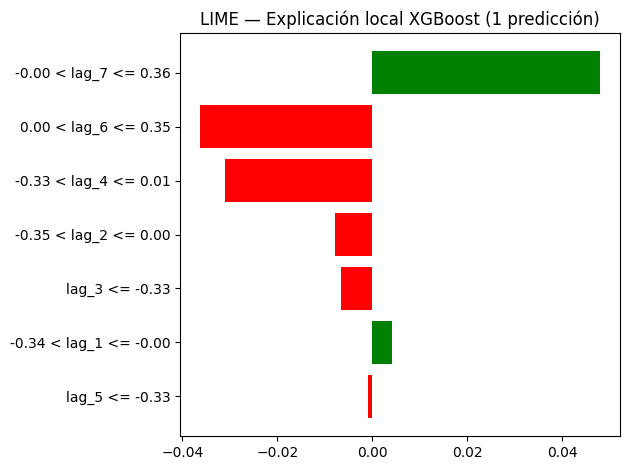

In [11]:
# LIME — interpretabilidad del XGBoost en el último fold
fold = len(X) - 1
X_tr = X[fold].reshape(X[fold].shape[0], -1)
X_te = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
y_tr = y[fold].reshape(-1)

scaler_x = StandardScaler().fit(X_tr)
scaler_y = StandardScaler().fit(y_tr.reshape(-1, 1))

X_train_s = scaler_x.transform(X_tr)
X_test_s  = scaler_x.transform(X_te)
y_train_s = scaler_y.transform(y_tr.reshape(-1, 1)).ravel()

xgb_lime = XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, verbosity=0)
xgb_lime.fit(X_train_s, y_train_s)

feature_names = [f'lag_{i+1}' for i in range(N_LAGS)]

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_s,
    feature_names=feature_names,
    mode='regression'
)

# Explicar una predicción puntual (índice 0 del test)
exp = explainer.explain_instance(X_test_s[0], xgb_lime.predict, num_features=N_LAGS)
exp.as_pyplot_figure()
plt.title('LIME — Explicación local XGBoost (1 predicción)')
plt.tight_layout()
plt.show()

### SVR

In [12]:
res_svr = entrenar_modelo(
    lambda: SVR(kernel='rbf', C=1.0, epsilon=0.01),
    X, y, Xcv, ycv, Xtest, ytest,
    nombre='SVR'
)

SVR                       — RMSE: 0.00276 | MAE: 0.00161


### Tabla comparativa de modelos benchmark

In [13]:
resultados_todos = [res_knn, res_ridge, res_lasso, res_dt, res_rf, res_xgb, res_svr]

tabla = pd.DataFrame([
    {'Modelo': r['nombre'], 'RMSE': round(r['rmse_avg'], 5), 'MAE': round(r['mae_avg'], 5)}
    for r in resultados_todos
]).sort_values('RMSE')

print(tabla.to_string(index=False))

       Modelo    RMSE     MAE
        Ridge 0.00270 0.00160
        Lasso 0.00270 0.00160
          SVR 0.00276 0.00161
Decision Tree 0.00277 0.00162
Random Forest 0.00278 0.00165
      XGBoost 0.00290 0.00169
          KNN 0.00292 0.00178


Los resultados muestran que Ridge y Lasso tuvieron el mejor desempeño con RMSE de 0.00270 y MAE de 0.00160, seguidos por SVR (RMSE: 0.00276) y Decision Tree (RMSE: 0.00277). Esto sugiere que la relación entre los lags y el retorno logarítmico es mayormente lineal los modelos más complejos como XGBoost y Random Forest no lograron capturar patrones adicionales.

KNN fue el modelo con peor desempeño (RMSE: 0.00292), lo cual puede ser debudo a que en series financieras de alta frecuencia los vecinos más cercanos en el espacio de features no necesariamente representan situaciones de mercado similares.



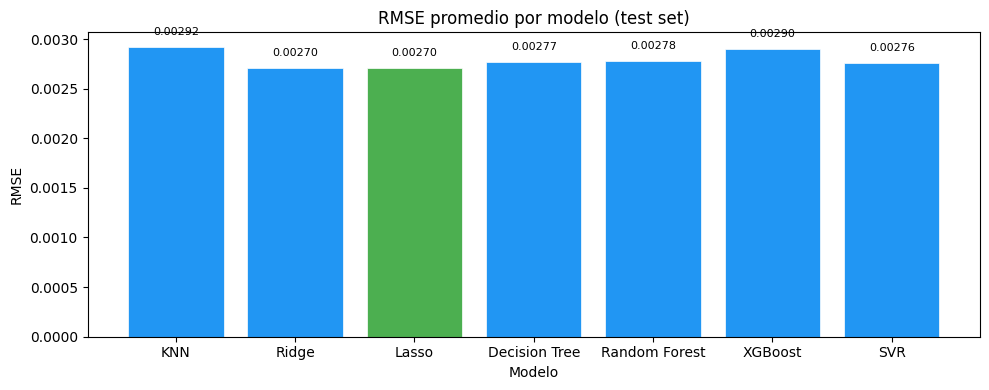

In [14]:
# Gráfica comparativa de RMSE por modelo
fig, ax = plt.subplots(figsize=(10, 4))
modelos = [r['nombre'] for r in resultados_todos]
rmses   = [r['rmse_avg'] for r in resultados_todos]

colores = ['#2196F3' if r != min(rmses) else '#4CAF50' for r in rmses]
bars = ax.bar(modelos, rmses, color=colores, edgecolor='white', linewidth=0.5)
ax.set_title('RMSE promedio por modelo (test set)')
ax.set_ylabel('RMSE')
ax.set_xlabel('Modelo')
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.5f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

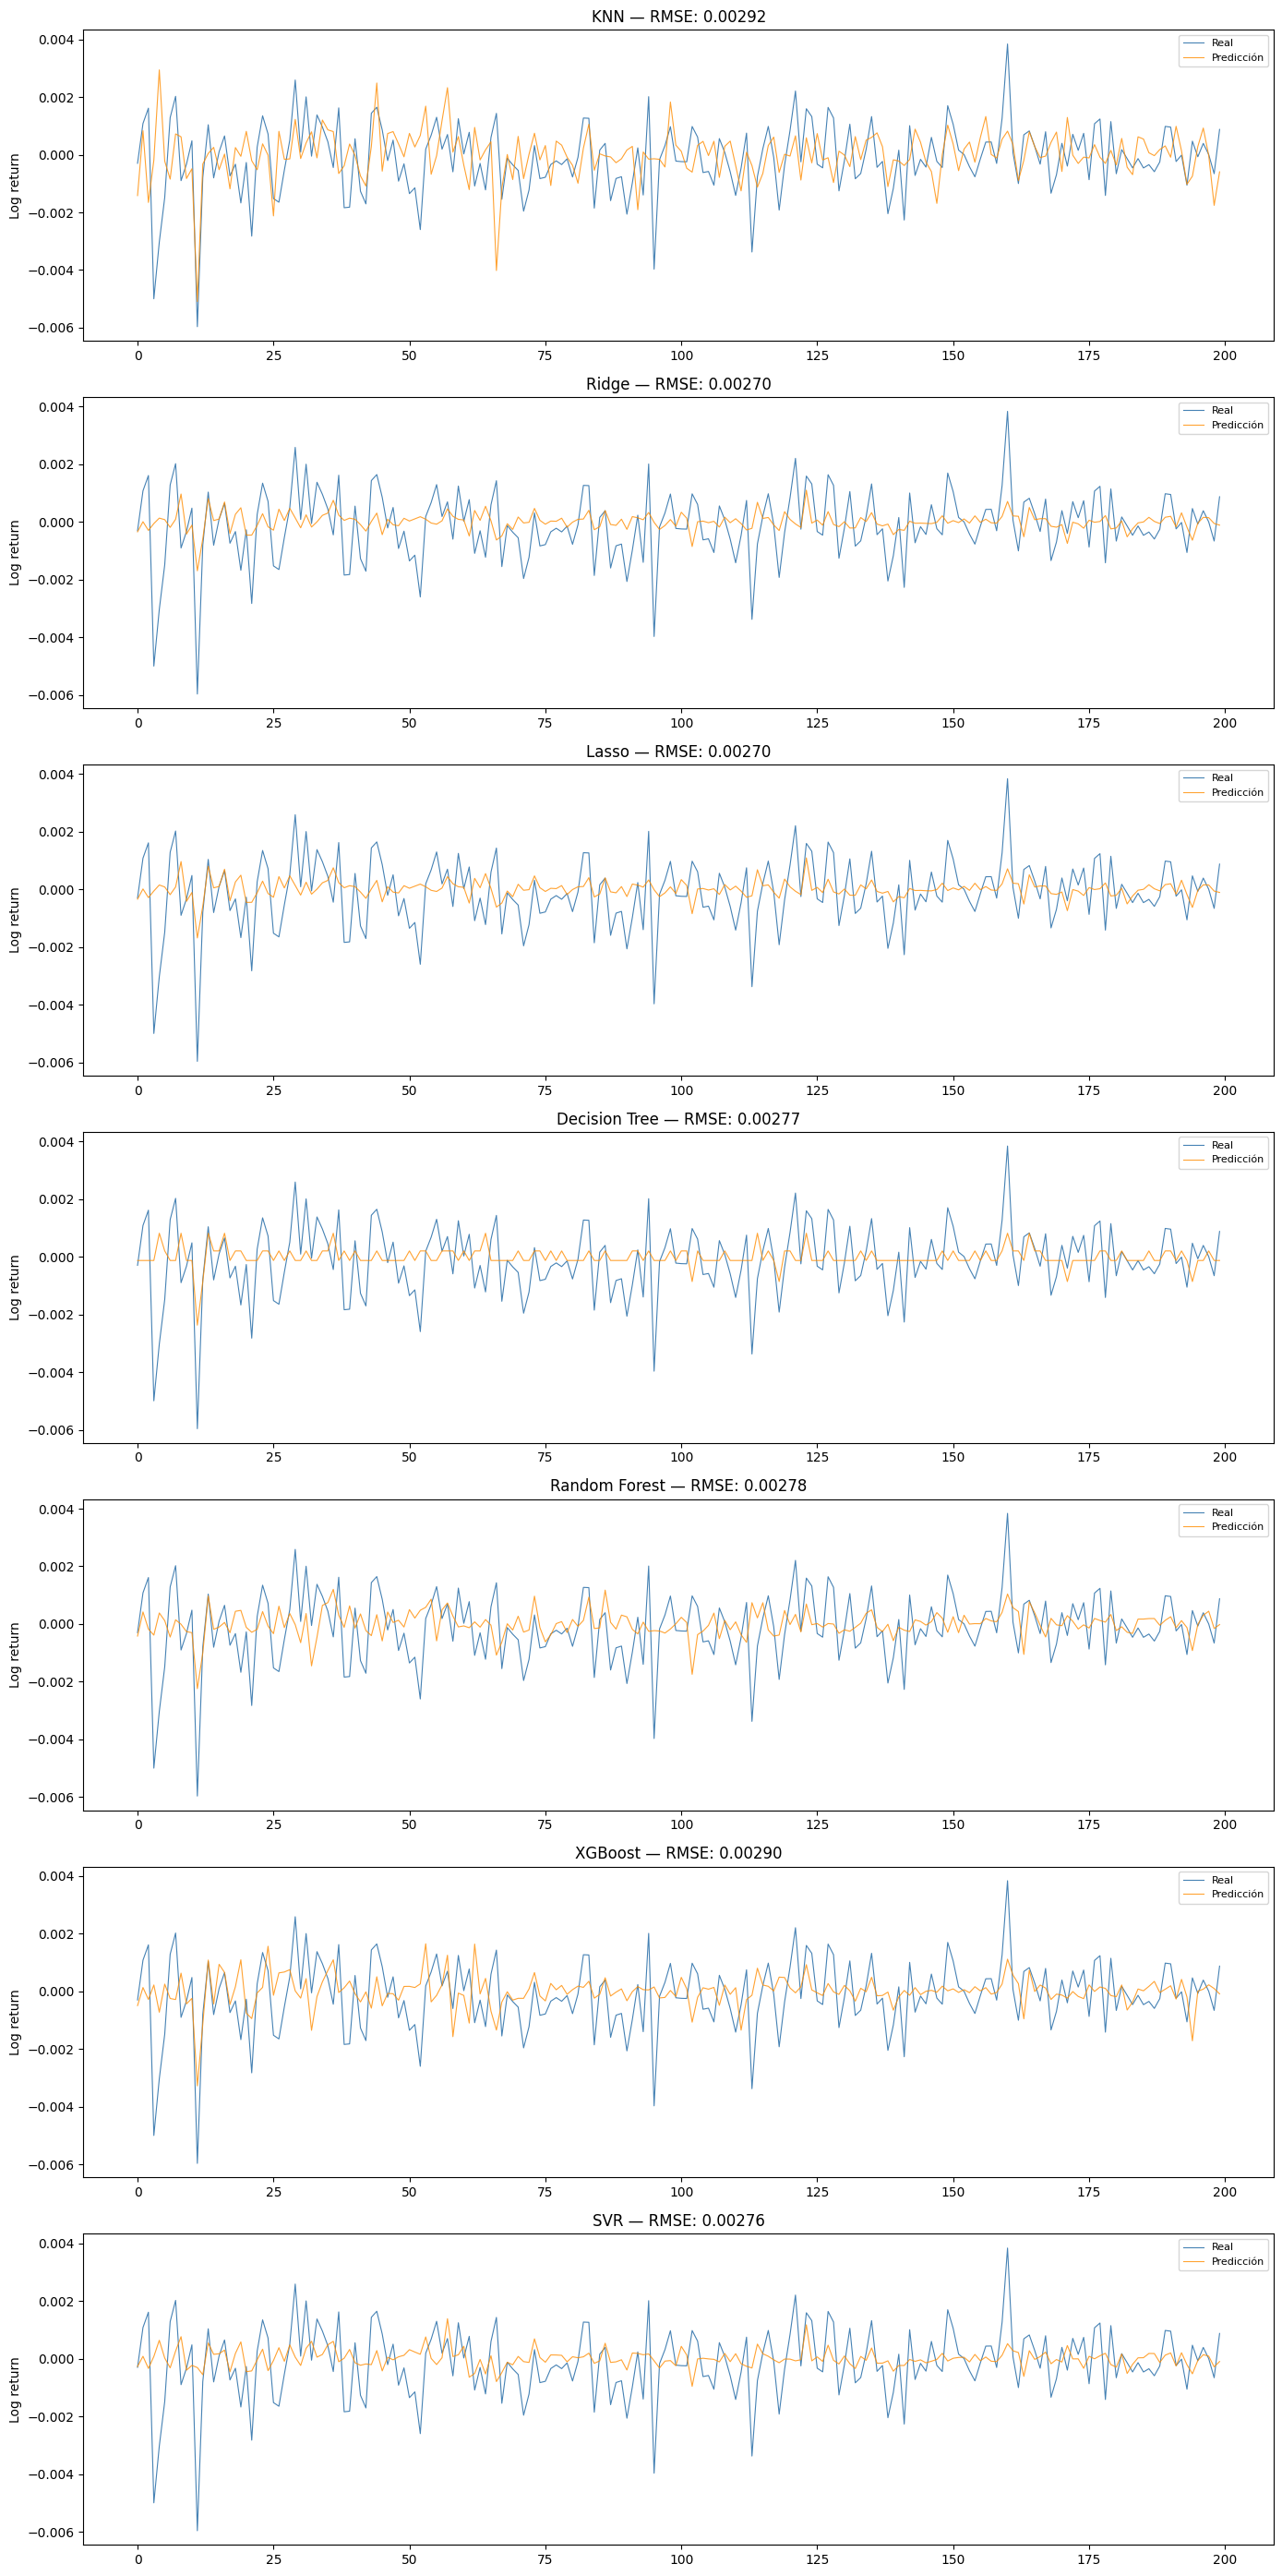

In [15]:
# Predicciones vs real  último fold de cada modelo
fig, axes = plt.subplots(len(resultados_todos), 1, figsize=(14, 4 * len(resultados_todos)))

n_mostrar = 200  # mostrar primeros 200 puntos del test para mayor claridad

for ax, res in zip(axes, resultados_todos):
    ax.plot(res['real'][:n_mostrar], label='Real', color='steelblue', linewidth=0.8)
    ax.plot(res['preds'][:n_mostrar], label='Predicción', color='darkorange',
            linewidth=0.8, alpha=0.8)
    ax.set_title(f"{res['nombre']} — RMSE: {res['rmse_avg']:.5f}")
    ax.set_ylabel('Log return')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Con estas graficas se puede confirmar visualmente lo que dicen las metricas. Se observa como la linea naranja (prediccion) es mas suave y menos volatil que la linea azul (real) en todos los modelos. Los modelos tienden a predecir valores cercanos a 0 lo cual tiene sentido dado a que la media es 0.0000011

Entre los modelos se puede ver como la prediccion de KNN salta mas pero sin seguir bien la señal real. Ridge y Lasso tienen la prediccion mas pegada a 0, lo que explica su menor RMSE. RandomForest y XGboost sigue mejor algunos movimientos pero suavizan los extremos.

## Análisis de residuos

Para cada modelo se verifican:
- **Independencia**: test de Ljung-Box (no debe haber autocorrelación en residuos)
- **Independencia no lineal**: test BDS
- **Distribución**: histograma de residuos
- **ACF**: función de autocorrelación de los residuos

In [16]:
from statsmodels.tsa.stattools import bds
from statsmodels.stats.diagnostic import acorr_ljungbox

resultados_residuos = []

for res in resultados_todos:
    resid = res['residuos']

    # Ljung-Box (lag 10)
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb_pval = lb['lb_pvalue'].values[0]

    # BDS
    resid_sample = resid[:2000]  # 2000 puntos es suficiente para el test
    bds_result = bds(resid_sample, max_dim=2)
    bds_pval = bds_result[1].item()

    resultados_residuos.append({
        'Modelo'         : res['nombre'],
        'Ljung-Box p-val': round(lb_pval, 4),
        'BDS p-val'      : round(bds_pval, 4),
        'Residuos indep.': 'Sí' if lb_pval > 0.05 else 'No'
    })

tabla_resid = pd.DataFrame(resultados_residuos)
print(tabla_resid.to_string(index=False))

       Modelo  Ljung-Box p-val  BDS p-val Residuos indep.
          KNN           0.0525     0.5251              Sí
        Ridge           0.0109     0.5595              No
        Lasso           0.0107     0.5596              No
Decision Tree           0.0001     0.5392              No
Random Forest           0.0701     0.5167              Sí
      XGBoost           0.0281     0.4867              No
          SVR           0.0922     0.5776              Sí


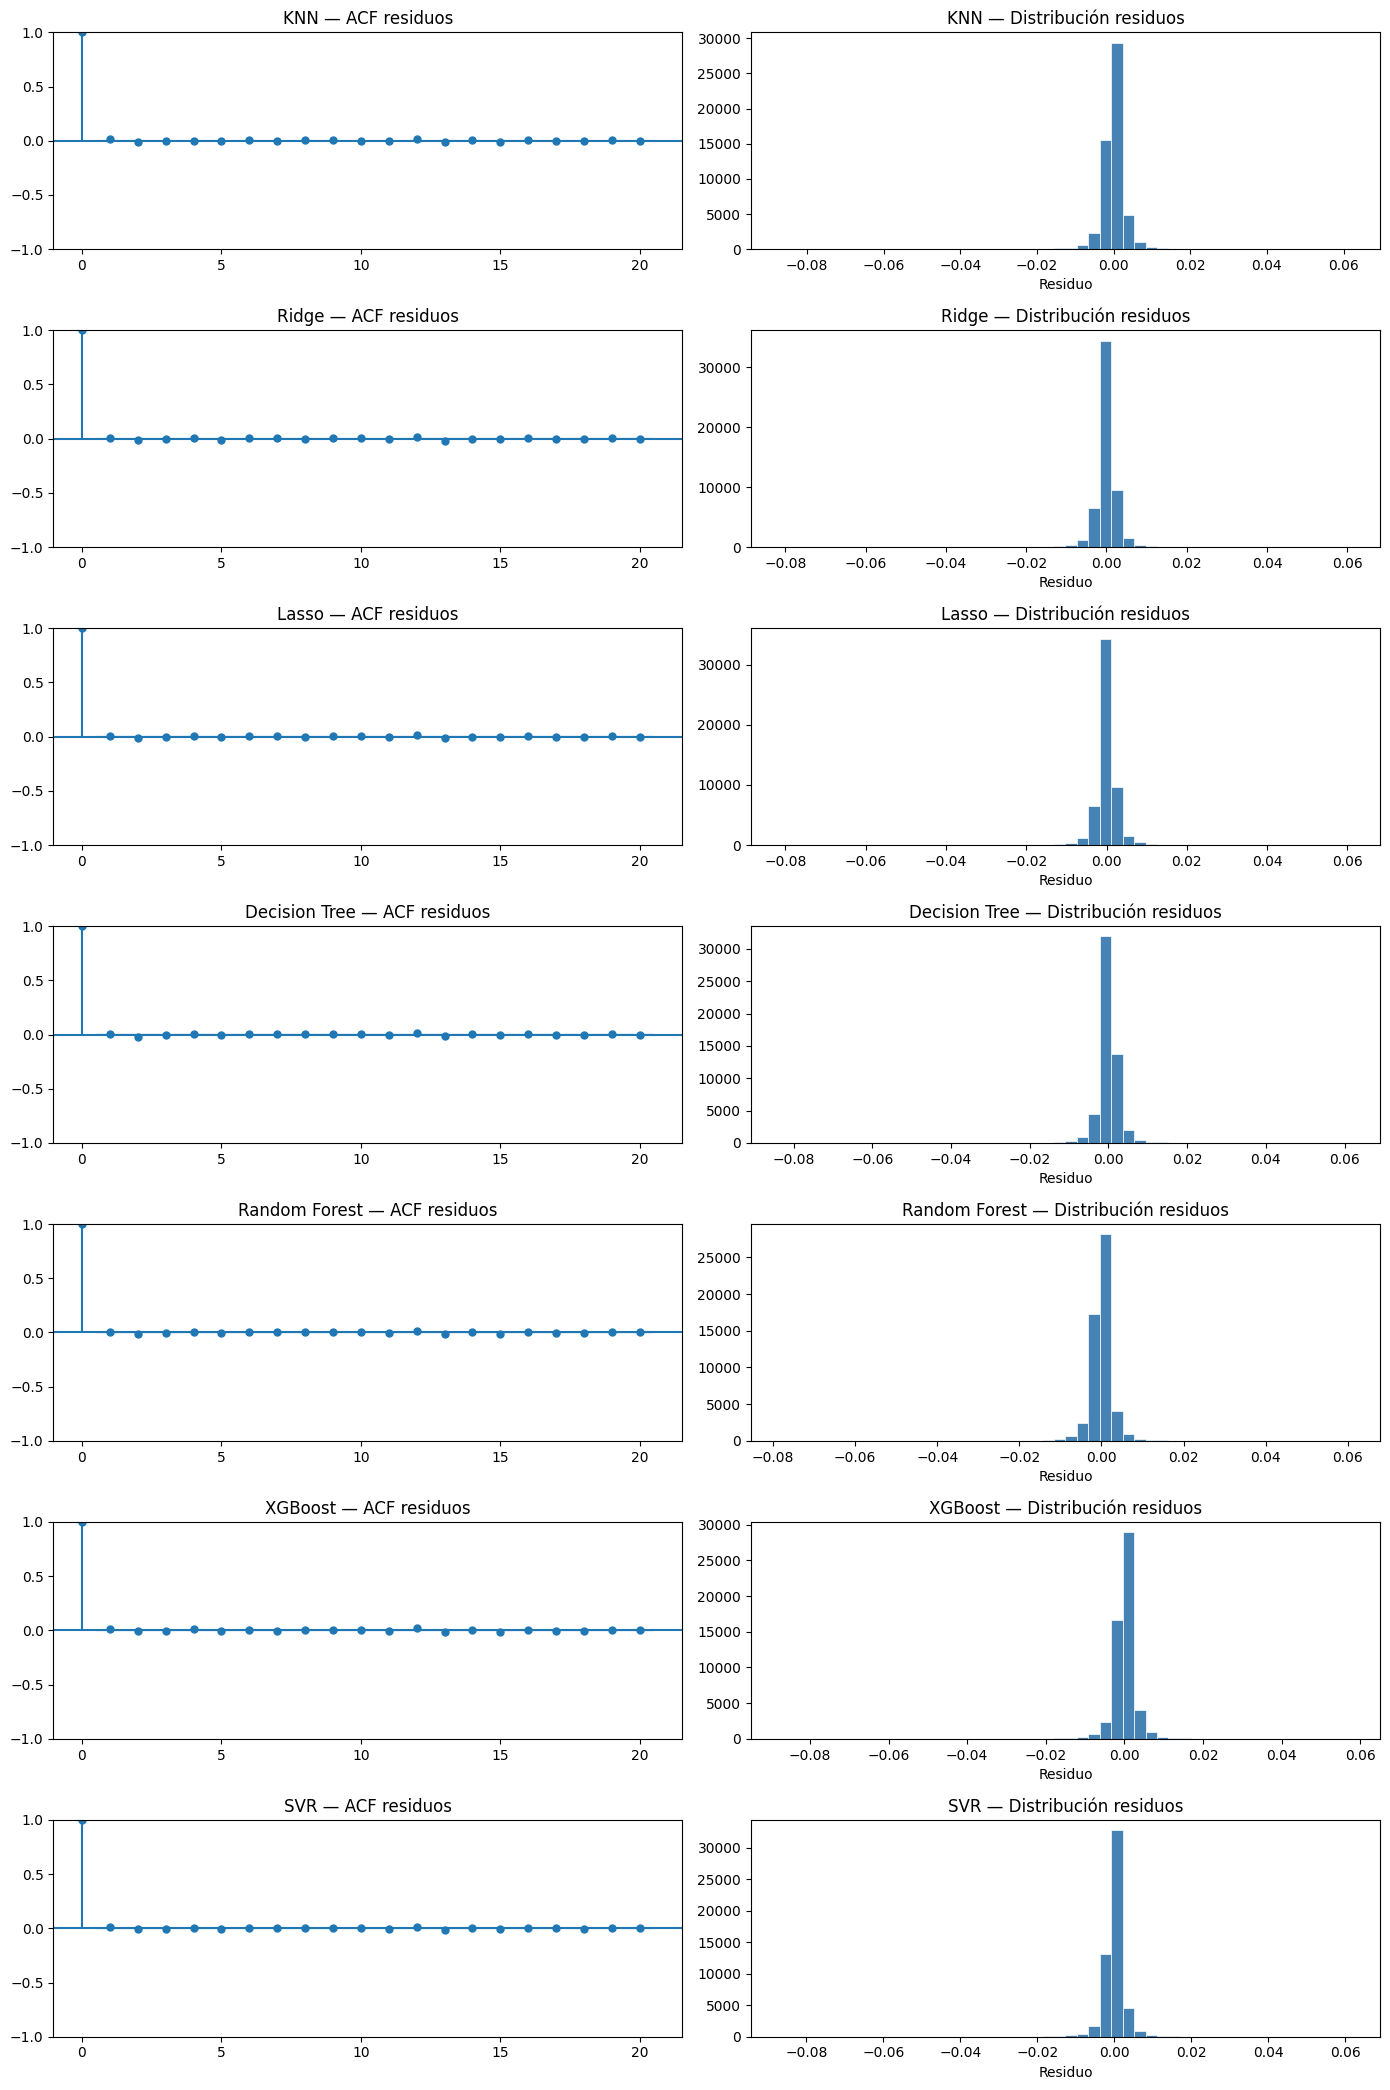

In [17]:
# ACF e histograma de residuos por modelo
fig, axes = plt.subplots(len(resultados_todos), 2, figsize=(14, 3 * len(resultados_todos)))

for i, res in enumerate(resultados_todos):
    resid = res['residuos']

    # ACF
    plot_acf(resid, lags=20, ax=axes[i, 0], alpha=0.05)
    axes[i, 0].set_title(f"{res['nombre']} — ACF residuos")

    # Histograma
    axes[i, 1].hist(resid, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i, 1].set_title(f"{res['nombre']} — Distribución residuos")
    axes[i, 1].set_xlabel('Residuo')

plt.tight_layout()
plt.show()

## Optimización de hiperparámetros

Se optimizan los hiperparámetros del mejor modelo de la sección anterior usando 4 métodos. En todos los casos el preprocesamiento está dentro del proceso de validación para evitar data leakage.

In [18]:
# Función de evaluación base — reutilizada por todos los métodos de optimización
# Recibe hiperparámetros, entrena en todos los folds y retorna RMSE promedio
def evaluar_xgb(params):
    """
    Evalúa un XGBRegressor con los params dados.
    El preprocesamiento se hace dentro de cada fold — sin data leakage.
    """
    rmses = []
    for fold in range(len(X)):
        X_tr = X[fold].reshape(X[fold].shape[0], -1)
        X_te = Xtest[fold].reshape(Xtest[fold].shape[0], -1)
        y_tr = y[fold].reshape(-1)
        y_te = ytest[fold].reshape(-1)

        scaler_x = StandardScaler().fit(X_tr)
        scaler_y = StandardScaler().fit(y_tr.reshape(-1, 1))

        X_train_s = scaler_x.transform(X_tr)
        X_test_s  = scaler_x.transform(X_te)
        y_train_s = scaler_y.transform(y_tr.reshape(-1, 1)).ravel()

        model = XGBRegressor(**params, random_state=RANDOM_SEED, verbosity=0)
        model.fit(X_train_s, y_train_s)

        yhat  = scaler_y.inverse_transform(model.predict(X_test_s).reshape(-1, 1)).ravel()
        rmses.append(np.sqrt(mean_squared_error(y_te, yhat)))

    return np.mean(rmses)

print('Función de evaluación lista')

Función de evaluación lista


### Grid Search

In [19]:
import time
from itertools import product

# Espacio de búsqueda
grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

t0 = time.time()
mejor_rmse_grid = np.inf
mejor_params_grid = {}
n_iter_grid = 0

keys = list(grid_params.keys())
for vals in product(*grid_params.values()):
    params = dict(zip(keys, vals))
    rmse = evaluar_xgb(params)
    n_iter_grid += 1
    if rmse < mejor_rmse_grid:
        mejor_rmse_grid   = rmse
        mejor_params_grid = params

t_grid = time.time() - t0
print(f'Grid Search — Mejor RMSE: {mejor_rmse_grid:.5f}')
print(f'Mejores params: {mejor_params_grid}')
print(f'Iteraciones: {n_iter_grid} | Tiempo: {t_grid:.1f}s')

Grid Search — Mejor RMSE: 0.00272
Mejores params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Iteraciones: 27 | Tiempo: 22.9s


### Random Search

In [20]:
from scipy.stats import randint, uniform

np.random.seed(RANDOM_SEED)
N_ITER_RANDOM = 27  # misma cantidad que grid para comparar justo

t0 = time.time()
mejor_rmse_random = np.inf
mejor_params_random = {}
history_random = []

for i in range(N_ITER_RANDOM):
    params = {
        'n_estimators' : int(np.random.choice([50, 100, 150, 200, 300])),
        'max_depth'    : int(np.random.randint(2, 10)),
        'learning_rate': float(10 ** np.random.uniform(-3, 0))  # escala logarítmica
    }
    rmse = evaluar_xgb(params)
    history_random.append(rmse)
    if rmse < mejor_rmse_random:
        mejor_rmse_random   = rmse
        mejor_params_random = params

t_random = time.time() - t0
print(f'Random Search — Mejor RMSE: {mejor_rmse_random:.5f}')
print(f'Mejores params: {mejor_params_random}')
print(f'Iteraciones: {N_ITER_RANDOM} | Tiempo: {t_random:.1f}s')

Random Search — Mejor RMSE: 0.00272
Mejores params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.022349221517675502}
Iteraciones: 27 | Tiempo: 45.1s
